# 43 · NIAMS · bulk_RNA_seq · PRE samples: SAVI against CANDLE

Reads `counts_raw.rds`, `counts_combatseq.rds` and `samples.rds` (notebook 40). Writes `de_NIAMS_PRE_SAVI-CANDLE.csv`
and `top_genes_NIAMS_PRE_SAVI-CANDLE.csv` in `data/run_artifacts/CANDLE_SAVI/`, and a heatmap to
`figures/CANDLE_SAVI/`.

**Samples.** The NIAMS samples with Treatment = PRE, from the 161 samples of notebook 40: CANDLE and SAVI.

**Method.** As in notebook 41: raw counts, limma-voom (Law CW et al. *Genome Biol* 2014;15:R29) with the
patient as a blocking factor (`duplicateCorrelation`; Smyth GK, Michaud J, Scott HS. *Bioinformatics*
2005;21:2067-2075); design `~ 0 + diagnosis + batch`, where batch is the NIAMS sequencing cohort. Top genes:
adjusted p < 0.05 and fold change at least 2.

**Heatmap.** As in notebook 42: the ComBat-seq counts of notebook 40, log2 counts per million, z-scored per
gene; Ward trees on both axes.

## PRE samples

In [1]:
source("../src/paths.R")
suppressMessages({library(limma); library(edgeR); library(ComplexHeatmap); library(circlize)})
x <- readRDS(art("CANDLE_SAVI", "counts_raw.rds")); s <- readRDS(art("CANDLE_SAVI", "samples.rds"))
pre <- s[s$Sequencing_Facility == "NIAMS" & s$Treatment == "PRE", ]
table(diagnosis = pre$diagnosis, batch = pre$batch)
c(samples = nrow(pre), patients = length(unique(pre$patient)))

         batch
diagnosis NIAMS-Batch1 NIAMS-unlabelled
   CANDLE           23                8
   SAVI             11                1

samples patients 
      43       16

**Explanation**
- `pre` keeps the NIAMS samples whose Treatment is PRE.
- The table crosses diagnosis with the NIAMS sequencing cohort; the last line counts samples and patients.

**Result.** 43 PRE samples from 16 patients: CANDLE 31 (Batch1 23, unlabelled 8), SAVI 12 (Batch1 11,
unlabelled 1).

## limma-voom with the patient as a block

In [2]:
pre$diagnosis <- factor(make.names(pre$diagnosis)); pre$batch <- factor(make.names(pre$batch))
design <- model.matrix(~ 0 + diagnosis + batch, pre); colnames(design) <- sub("^diagnosis", "", colnames(design))
dge  <- DGEList(x$counts[, pre$sample], genes = x$genes)
keep <- filterByExpr(dge, design); dge <- calcNormFactors(dge[keep, , keep.lib.sizes = FALSE])
v    <- voom(dge, design)
cor1 <- duplicateCorrelation(v, design, block = pre$patient)$consensus
v    <- voom(dge, design, block = pre$patient, correlation = cor1)
cor2 <- duplicateCorrelation(v, design, block = pre$patient)$consensus
fit  <- eBayes(contrasts.fit(lmFit(v, design, block = pre$patient, correlation = cor2),
                             makeContrasts(SAVI - CANDLE, levels = design)))
tab  <- topTable(fit, coef = 1, number = Inf, sort.by = "P")
top  <- tab[tab$adj.P.Val < 0.05 & abs(tab$logFC) >= 1, c("gene_id", "gene_name", "logFC", "AveExpr", "adj.P.Val")]
c(genes_kept = sum(keep), correlation = round(cor2, 3), adj_p_below_0.05 = sum(tab$adj.P.Val < 0.05),
  top_up = sum(top$logFC > 0), top_down = sum(top$logFC < 0))
write.csv(tab, art("CANDLE_SAVI", "de_NIAMS_PRE_SAVI-CANDLE.csv"), row.names = FALSE)
write.csv(top, art("CANDLE_SAVI", "top_genes_NIAMS_PRE_SAVI-CANDLE.csv"), row.names = FALSE)
print(head(transform(top, logFC = round(logFC, 2), AveExpr = round(AveExpr, 1), adj.P.Val = signif(adj.P.Val, 2)), 15), row.names = FALSE)

genes_kept      correlation adj_p_below_0.05           top_up 
       23876.000            0.201           56.000           33.000 
        top_down 
          13.000

         gene_id    gene_name logFC AveExpr adj.P.Val
 ENSG00000263155        MYZAP  2.06     0.7    0.0031
 ENSG00000151650        VENTX  1.99     1.9    0.0055
 ENSG00000154856       APCDD1  1.60     0.0    0.0120
 ENSG00000051128       HOMER3  1.60     2.6    0.0120
 ENSG00000188487         INSC  2.32    -0.1    0.0120
 ENSG00000164512      ANKRD55 -1.04     3.7    0.0130
 ENSG00000154451         GBP5 -2.00     9.4    0.0130
 ENSG00000237568 RP4-620F22.2 -2.01     8.8    0.0130
 ENSG00000204001         LCN8  3.66    -2.0    0.0130
 ENSG00000161714        PLCD3  1.03     0.5    0.0130
 ENSG00000085449        WDFY1 -1.27     6.1    0.0130
 ENSG00000100505        TRIM9  2.25     1.4    0.0140
 ENSG00000262001   DLGAP1-AS2  1.18     1.4    0.0240
 ENSG00000223563   AP001601.2  2.81    -3.2    0.0240
 ENSG00000143067       ZNF697  1.32     0.6    0.0240


**Explanation**
- The design, filter, voom, `duplicateCorrelation` and fit are those of notebook 41, on the PRE samples only.
- `makeContrasts(SAVI - CANDLE, levels = design)` is the one comparison: a positive log2 fold change means
  higher in SAVI.
- `top` keeps the genes with adjusted p < 0.05 and |log2 fold change| >= 1; the full table and the top genes
  are written as CSV files, and the 15 top genes with the smallest adjusted p are printed.

**Result.** 23,876 genes pass the filter; the correlation between samples of the same patient is 0.201. 56 genes
have adjusted p < 0.05; 46 of them also have a fold change of at least 2: 33 higher in SAVI and 13 higher in
CANDLE. Higher in CANDLE are, among others, GBP5, WDFY1 and ANKRD55; higher in SAVI MYZAP, VENTX, APCDD1, HOMER3,
INSC, LCN8 and TRIM9. INSC, APCDD1 and TRIM9 are also among the top genes of SAVI against CANDLE over all samples
(notebook 41).

## Heatmap

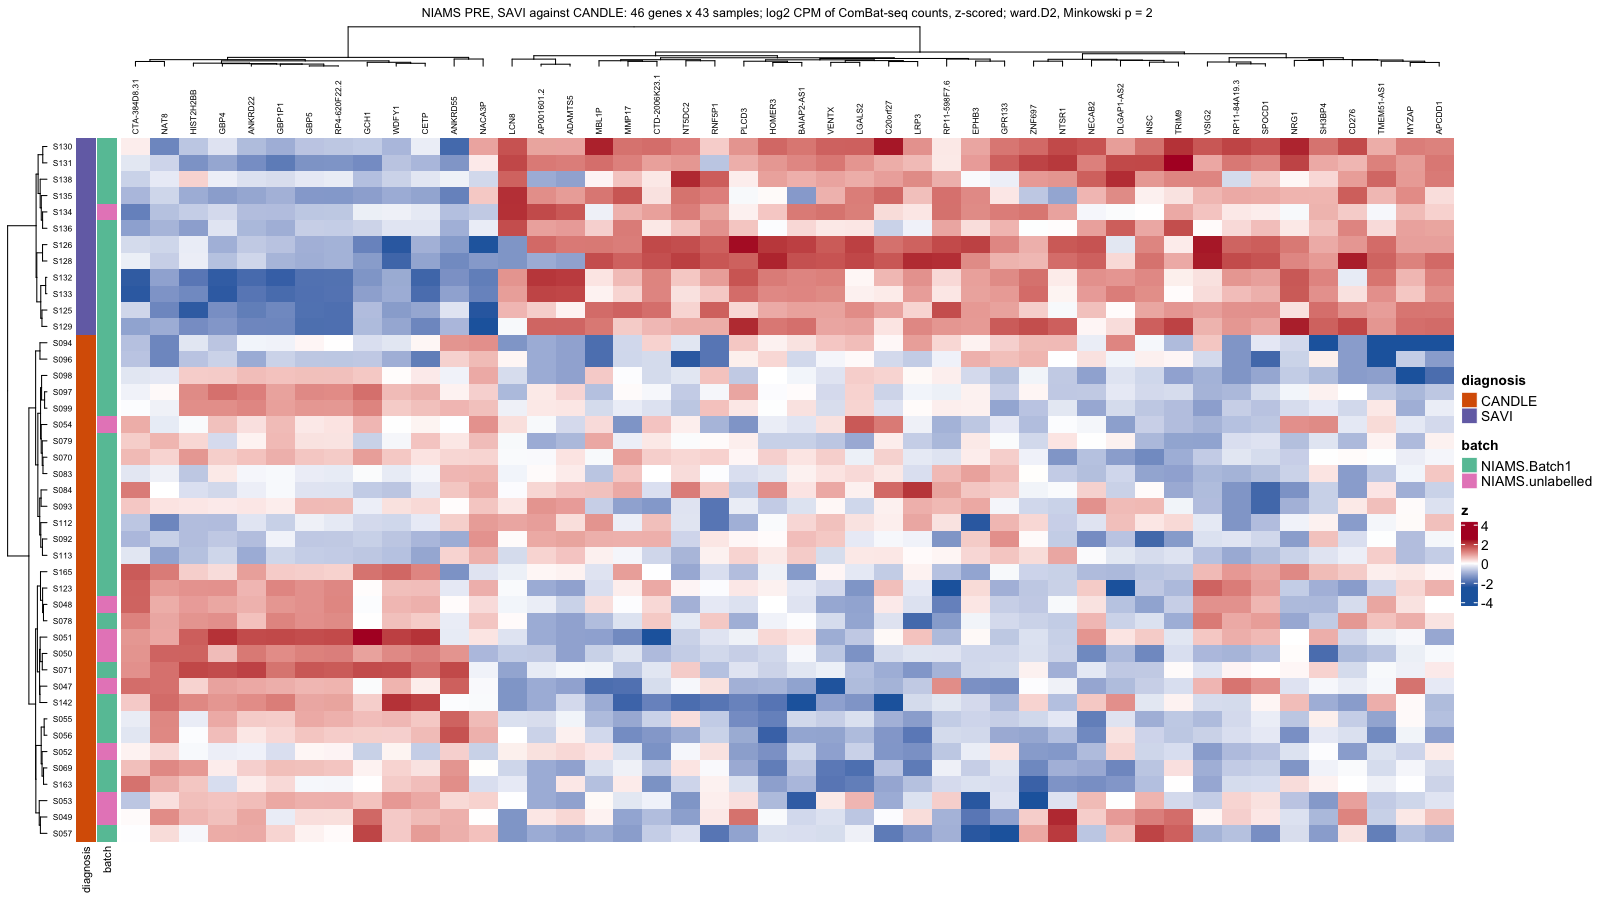

      diagnosis
branch CANDLE SAVI
     1     31    0
     2      0   12

In [3]:
xc <- readRDS(art("CANDLE_SAVI", "counts_combatseq.rds"))
logcpm <- cpm(calcNormFactors(DGEList(xc$counts[, pre$sample])), log = TRUE)
H  <- scale(t(logcpm[top$gene_id, , drop = FALSE])); H <- H[, colSums(is.na(H)) == 0, drop = FALSE]
Hc <- pmin(pmax(H, -2.5), 2.5)
hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
left <- rowAnnotation(diagnosis = as.character(pre$diagnosis), batch = as.character(pre$batch),
                      col = list(diagnosis = c(CANDLE = "#D95F02", SAVI = "#7570B3"),
                                 batch = c(NIAMS.Batch1 = "#66C2A5", NIAMS.unlabelled = "#E78AC3")),
                      annotation_name_gp = gpar(fontsize = 8))
ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
              cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top", column_names_side = "top", row_names_side = "left",
              row_names_gp = gpar(fontsize = 6),
              column_labels = top$gene_name[match(colnames(H), top$gene_id)], column_names_gp = gpar(fontsize = 6),
              left_annotation = left, column_title_gp = gpar(fontsize = 9),
              column_title = sprintf("NIAMS PRE, SAVI against CANDLE: %d genes x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", ncol(H), nrow(H)))
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "43_heatmap_NIAMS_PRE.png") else tempfile(fileext = ".png")
  png(f, width = 16, height = 9, units = "in", res = res); draw(ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(hr, 2), diagnosis = pre$diagnosis)

**Explanation**
- The ComBat-seq counts of the PRE samples, log2 counts per million, z-scored per top gene; colours capped at
  -2.5 and 2.5.
- `hr` and `hc` are Ward trees of the samples and the genes; the strips show diagnosis and cohort.
- The heatmap is saved at 300 dpi and shown at 100 dpi, as in notebook 42.
- `cutree(hr, 2)` gives the first split of the sample tree; the table crosses it with diagnosis.

**Result.** The first split of the sample tree separates all 31 CANDLE samples from all 12 SAVI samples.

## The 28 interferon response genes and the 11 NF-kB-only controls

In [4]:
GENES <- xc$genes
irg <- read_gene_set("ifn-response-genes-28.txt"); nfk <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
dj3 <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
ifn <- data.frame(gene_name = c(irg, nfk), set = rep(c("IRG-28", "NF-kB-11"), c(length(irg), length(nfk))))
ifn$subscore <- ifelse(ifn$set == "NF-kB-11", "control", ifelse(ifn$gene_name %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"))
ifn$gene_id  <- GENES$gene_id[match(ifn$gene_name, GENES$gene_name)]
ifn_heat <- function(logcpm, left, title) {
  g  <- ifn[!is.na(ifn$gene_id), ]
  H  <- scale(t(logcpm[g$gene_id, , drop = FALSE])); keep <- colSums(is.na(H)) == 0
  H  <- H[, keep, drop = FALSE]; g <- g[keep, ]; Hc <- pmin(pmax(H, -2.5), 2.5)
  hr <- hclust(dist(H, method = "minkowski", p = 2), method = "ward.D2")
  hc <- hclust(dist(t(H), method = "minkowski", p = 2), method = "ward.D2")
  top_ann <- HeatmapAnnotation(set = g$set, subscore = g$subscore,
                               col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40"),
                                          subscore = c("25 STAT1-only" = "steelblue", "3 STAT1/NF-kB" = "firebrick", control = "grey80")),
                               annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Hc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hc, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 5), column_labels = g$gene_name,
                column_names_side = "top", column_names_gp = gpar(fontsize = 8),
                top_annotation = top_ann, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("%s: 28 interferon response genes and 11 NF-kB-only controls x %d samples; log2 CPM of ComBat-seq counts, z-scored; ward.D2, Minkowski p = 2", title, nrow(H)))
  list(ht = ht, rows = hr, cols = hc, genes = g)
}
c(interferon_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "IRG-28"])), control_genes_found = sum(!is.na(ifn$gene_id[ifn$set == "NF-kB-11"])))

interferon_genes_found    control_genes_found 
                    28                     11

**Explanation**
- The gene lists are those of notebooks 05c, 15c and 26c (`genes/`, see notebook 00 for `read_gene_set()`):
  - `ifn-response-genes-28.txt`: the 28 interferon response genes listed in Kim H et al. *J Interferon
    Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al. *J Clin Invest*
    2020;130:1669-1682 (Supplemental Figure 3B);
  - `ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`: CXCL10, GBP1 and SOCS1, which de Jesus 2020 separates
    as genes with STAT1 and NF-kB binding sites; the other 25 are STAT1-only;
  - `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site,
    the control (de Jesus 2020).
- `ifn` lists the 39 genes with their set and subscore; `gene_id` finds each gene's Ensembl identifier by its
  name in these data.
- `ifn_heat(logcpm, left, title)` draws the heatmap: samples as rows, genes as columns, each gene z-scored,
  colours capped at -2.5 and 2.5; Ward trees on both axes; strips on top for set and subscore, and `left` for
  the samples. It returns the heatmap and the two trees.
- The last line counts the genes found.

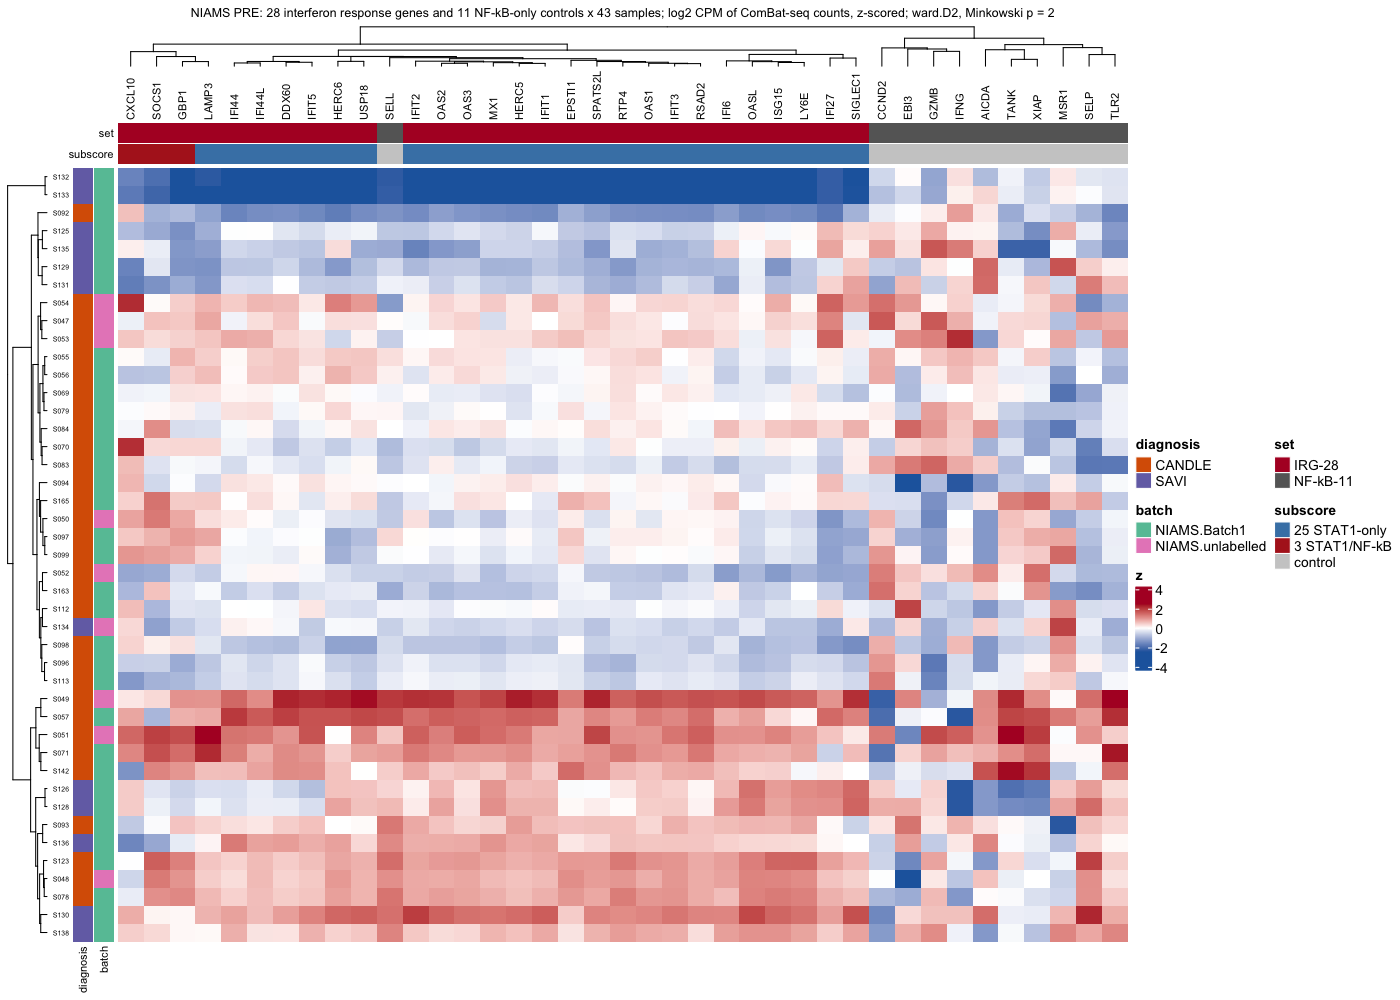

      diagnosis
branch CANDLE SAVI
     1     31   10
     2      0    2

$`1`
 [1] "CXCL10"  "DDX60"   "EPSTI1"  "GBP1"    "HERC5"   "HERC6"   "IFI27"  
 [8] "IFI44"   "IFI44L"  "IFI6"    "IFIT1"   "IFIT2"   "IFIT3"   "IFIT5"  
[15] "ISG15"   "LAMP3"   "LY6E"    "MX1"     "OAS1"    "OAS2"    "OAS3"   
[22] "OASL"    "RSAD2"   "RTP4"    "SIGLEC1" "SOCS1"   "SPATS2L" "USP18"  
[29] "SELL"   

$`2`
 [1] "AICDA" "CCND2" "EBI3"  "GZMB"  "IFNG"  "MSR1"  "SELP"  "TANK"  "TLR2" 
[10] "XIAP"

In [5]:
r <- ifn_heat(logcpm, left, "NIAMS PRE")
for (res in c(300, 100)) {                          # a 300 dpi PNG kept, a 100 dpi copy shown here
  f <- if (res == 300) fig("CANDLE_SAVI", "43_interferon_heatmap_NIAMS_PRE.png") else tempfile(fileext = ".png")
  png(f, width = 14, height = 10, units = "in", res = res); draw(r$ht); invisible(dev.off())
}
IRdisplay::display_png(file = f)
table(branch = cutree(r$rows, 2), diagnosis = pre$diagnosis)
split(r$genes$gene_name, cutree(r$cols, 2))

**Explanation**
- `ifn_heat()` draws the heatmap; it is saved at 300 dpi and shown at 100 dpi.
- `cutree(r$rows, 2)` gives the first split of the sample tree, crossed with the samples' labels;
  `cutree(r$cols, 2)` gives the first split of the gene tree, listed by branch.

**Result.** The first split of the gene tree separates the 28 interferon response genes, with SELL, from the other
10 NF-kB-only controls. The first split of the sample tree sets 2 SAVI samples with low interferon values apart
(mean z of the 28 genes -2.89) from the other 41 (0.14). The median z of the 28 genes is 0.06 in CANDLE and -0.39
in SAVI.

## References

The methods, gene lists and software used in this notebook.

1. R Core Team. *R: A Language and Environment for Statistical Computing*. R Foundation for Statistical Computing, Vienna, Austria.
2. Ritchie ME, Phipson B, Wu D, Hu Y, Law CW, Shi W, Smyth GK. limma powers differential expression analyses for RNA-sequencing and microarray studies. *Nucleic Acids Res* 2015;43:e47.
3. Smyth GK et al. *limma: Linear Models for Microarray and RNA-Seq Data. User's Guide*. Bioconductor.
4. Robinson MD, McCarthy DJ, Smyth GK. edgeR: a Bioconductor package for differential expression analysis of digital gene expression data. *Bioinformatics* 2010;26:139-140.
5. Robinson MD, Oshlack A. A scaling normalization method for differential expression analysis of RNA-seq data. *Genome Biol* 2010;11:R25.
6. Chen Y, Lun ATL, Smyth GK. From reads to genes to pathways: differential expression analysis of RNA-Seq experiments using Rsubread and the edgeR quasi-likelihood pipeline. *F1000Research* 2016;5:1438.
7. Law CW, Chen Y, Shi W, Smyth GK. voom: precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biol* 2014;15:R29.
8. Smyth GK, Michaud J, Scott HS. Use of within-array replicate spots for assessing differential expression in microarray experiments. *Bioinformatics* 2005;21:2067-2075.
9. Smyth GK. Linear models and empirical Bayes methods for assessing differential expression in microarray experiments. *Stat Appl Genet Mol Biol* 2004;3:Article3.
10. Benjamini Y, Hochberg Y. Controlling the false discovery rate: a practical and powerful approach to multiple testing. *J R Stat Soc B* 1995;57:289-300.
11. Love MI, Anders S, Kim V, Huber W. RNA-seq workflow: gene-level exploratory analysis and differential expression. *F1000Research* 2015;4:1070.
12. Gu Z, Eils R, Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics* 2016;32:2847-2849.
13. Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics* 2014;30:2811-2812.
14. Ward JH. Hierarchical grouping to optimize an objective function. *J Am Stat Assoc* 1963;58:236-244.
15. Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *J Classif* 2014;31:274-295.
16. Kim H, de Jesus AA, Brooks SR, Liu Y, Huang Y, VanTries R, et al. Development of a validated interferon score using NanoString technology. *J Interferon Cytokine Res* 2018;38:171-185.
17. de Jesus AA, Hou Y, Brooks S, Malle L, Biancotto A, Huang Y, et al. Distinct interferon signatures and cytokine patterns define additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669-1682.